# Forschungsfrage 1 - Duplikate: Traditioneller Ansatz (Exact Matching + RapidFuzz)

Dieses Notebook implementiert den **geleneksel/regelbasierten** Ansatz zur Duplikaterkennung
(vgl. Abschnitt 3.3.1): eine additive Regel-Scoring-Funktion ohne trainiertes Modell, bestehend
aus (1) normalisiertem Exact Matching auf `url` und (2) unscharfem String-Matching (RapidFuzz,
`token_sort_ratio`) auf `title`, ergänzt um schwache Zusatzsignale (`author`, `price`,
`creation_date`). Dieser additive Scoring-Ansatz ist bewusst so gewählt, dass er später als
konzeptioneller Vorläufer zum probabilistischen Fellegi-Sunter-Modell von Splink (Abschnitt
4.1.2) dient - beide summieren Evidenz aus mehreren Feldern, aber Splink lernt die Gewichte
statistisch (Expectation-Maximization), während dieser Ansatz sie fest vorgibt.

**Wichtiger Designpunkt 1 (aus der Analyse der Benchmark-Erzeugung, `01_Benchmark_...ipynb`):**
Bei 40 % der synthetischen Duplikat-Zwillinge wird der `url`-Wert um einen Query-Parameter
(`?ref=repost<id>`) ergänzt. Eine reine `url == url`-Prüfung würde diese Fälle verfehlen.
Die `url` wird daher vor dem Vergleich normalisiert (Query-String entfernt).

**Wichtiger Designpunkt 2 (empirisch entdeckt, siehe Abschnitt 6 unten):** Ein erster
Testlauf mit naiver Query-String-Entfernung erzeugte 8 Falsch-Positive, davon 6 durch
Amazon-Affiliate-Redirect-Links (`amazon.ca/gp/redirect.html?location=<eigentliche-URL>&tag=...`):
Da *alle* Amazon-Angebote über denselben Redirect-Pfad laufen, wurden ohne Sonderbehandlung
alle Amazon-Deals als "identische URL" erkannt, unabhängig vom tatsächlichen Produkt. Die
finale `normalize_url()`-Funktion erkennt bekannte Redirect-Parameter und entpackt die darin
codierte echte Ziel-URL, bevor normalisiert wird.

**Verwendete Daten:** `benchmark/tf1_duplicate_pool.csv` und `benchmark/tf1_duplicate_pairs.csv`
- identisch zu den Daten, die auch `Forschungsfrage_1_Duplikate_XGBoost.ipynb` und
`Forschungsfrage_1_Duplikate_LLM.ipynb` verwenden, damit alle Methoden auf demselben
`test`-Split verglichen werden können.


## 1. Setup und Daten laden

In [1]:
import pandas as pd
import numpy as np
import re
import json
import time
import os
from urllib.parse import urlsplit, parse_qs, unquote
import html

from rapidfuzz import fuzz
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

os.makedirs("results", exist_ok=True)

pool = pd.read_csv("benchmark/tf1_duplicate_pool.csv").set_index("row_id")
pairs = pd.read_csv("benchmark/tf1_duplicate_pairs.csv")

print(f"Pool: {pool.shape[0]} Zeilen ({pool['is_synthetic'].sum()} davon synthetisch)")
print(f"Paare: {pairs.shape[0]} ({pairs['label'].sum()} Duplikate, {(pairs['label']==0).sum()} Nicht-Duplikate)")
print(pairs["split"].value_counts())


Pool: 1476 Zeilen (150 davon synthetisch)
Paare: 736 (184 Duplikate, 552 Nicht-Duplikate)
split
train    441
test     148
val      147
Name: count, dtype: int64


## 2. Merkmalsfunktionen

Vier Signale, jedes einzeln nachvollziehbar (kein Black-Box-Modell):
1. `url_score` (0 oder 100): normalisierte URL (ohne Query-String/Fragment) identisch?
2. `title_score` (0-100): RapidFuzz `token_sort_ratio` auf kleingeschriebenem Titel.
3. Zusatz-Boni (je +5, additiv, gedeckelt bei 100): gleicher `author`, numerisch gleicher
   `price` (Toleranz 0.01), Zeitdifferenz `creation_date` <= 72 Stunden.


In [2]:
def normalize_url(u):
    """Normalisiert eine URL fuer den Vergleich.

    Zwei Faelle wurden bei der Fehleranalyse (Abschnitt 6) entdeckt und muessen behandelt werden:
    1. '?ref=repost<id>'-Anhaengsel bei 40% der synthetischen Duplikate (vgl. Benchmark-Erzeugung)
       - einfaches Entfernen des Query-Strings loest das.
    2. Amazon-Affiliate-Redirect-Links (z.B. 'amazon.ca/gp/redirect.html?location=<echte-URL>&tag=...'):
       Alle Amazon-Angebote laufen ueber denselben Redirect-Pfad, die eigentliche Produkt-URL steckt
       verschluesselt im 'location'-Query-Parameter. Ohne Behandlung wuerden dadurch ALLE
       Amazon-Angebote faelschlich als identische URL erkannt (6 von 8 Falsch-Positiven in einem
       ersten Testlauf gingen auf genau dieses Problem zurueck). Loesung: bekannte Redirect-Parameter
       ('location', 'url', 'u', 'q', 'dest') werden erkannt, dekodiert und die darin enthaltene
       echte Ziel-URL wird rekursiv normalisiert.
    3. Die rohen URLs enthalten HTML-Entities (`&amp;` statt `&`), wodurch `parse_qs()` die
       Query-Parameter nicht korrekt trennen kann (der gesamte Rest landet unter dem ersten
       Parameter, z.B. 'ie'). Deshalb wird zuerst `html.unescape()` angewendet.
    """
    if pd.isna(u):
        return None
    s = html.unescape(str(u).strip())
    if not s:
        return None
    parts = urlsplit(s)
    qs = parse_qs(parts.query)
    for key in ("location", "url", "u", "q", "dest"):
        if key in qs and qs[key]:
            inner = unquote(qs[key][0])
            if inner and inner != s:
                return normalize_url(inner)
    path = parts.path.rstrip("/")
    return f"{parts.netloc}{path}".lower()

def extract_price_num(val):
    if pd.isna(val):
        return np.nan
    m = re.search(r"(\d+(?:\.\d+)?)", str(val))
    return float(m.group(1)) if m else np.nan

def parse_pool_date(s):
    """Pool-Daten liegen durchgaengig im Rohformat vor ('Jul 16th, 2020 8:29 am'),
    da synthetische Zwillinge mit format_like_raw() erzeugt wurden (vgl. Benchmark-Notebook)."""
    if pd.isna(s):
        return pd.NaT
    s2 = re.sub(r"(\d+)(st|nd|rd|th)", r"\1", str(s))
    try:
        return pd.to_datetime(s2, format="%b %d, %Y %I:%M %p")
    except ValueError:
        return pd.to_datetime(s2, errors="coerce")

def compute_score(row_a, row_b):
    url_a, url_b = normalize_url(row_a["url"]), normalize_url(row_b["url"])
    url_score = 100.0 if (url_a is not None and url_b is not None and url_a == url_b) else 0.0

    title_score = fuzz.token_sort_ratio(str(row_a["title"]).lower(), str(row_b["title"]).lower())

    base_score = max(url_score, title_score)

    bonus = 0.0
    if pd.notna(row_a["author"]) and pd.notna(row_b["author"]) and row_a["author"] == row_b["author"]:
        bonus += 5.0
    pa, pb = extract_price_num(row_a["price"]), extract_price_num(row_b["price"])
    if pd.notna(pa) and pd.notna(pb) and abs(pa - pb) < 0.01:
        bonus += 5.0
    da, db = parse_pool_date(row_a["creation_date"]), parse_pool_date(row_b["creation_date"])
    if pd.notna(da) and pd.notna(db) and abs((da - db).total_seconds()) / 3600 <= 72:
        bonus += 5.0

    return min(100.0, base_score + bonus), url_score, title_score, bonus

# Kurzer Funktionstest an einem bekannten positiven Paar
_test_pair = pairs[pairs["label"] == 1].iloc[0]
_a, _b = pool.loc[_test_pair["row_id_a"]], pool.loc[_test_pair["row_id_b"]]
print("Beispiel (label=1):", compute_score(_a, _b))


Beispiel (label=1): (100.0, 100.0, 66.66666666666667, 10.0)


## 3. Scores für alle Paare berechnen

In [3]:
t0 = time.time()
scores = []
for _, p in pairs.iterrows():
    a, b = pool.loc[p["row_id_a"]], pool.loc[p["row_id_b"]]
    total, url_s, title_s, bonus = compute_score(a, b)
    scores.append({
        "row_id_a": p["row_id_a"], "row_id_b": p["row_id_b"], "label": p["label"], "split": p["split"],
        "url_score": url_s, "title_score": title_s, "bonus": bonus, "similarity_score": total,
    })
scored = pd.DataFrame(scores)
compute_time = time.time() - t0
print(f"{len(scored)} Paare in {compute_time:.3f}s bewertet ({compute_time/len(scored)*1000:.2f} ms/Paar).")
scored.head()


736 Paare in 0.625s bewertet (0.85 ms/Paar).


,row_id_a,row_id_b,label,split,url_score,title_score,bonus,similarity_score
0,2,177,1,val,100.0,66.666667,10.0,100.0
1,9,1381,1,val,100.0,98.969072,10.0,100.0
2,23,29,1,val,100.0,100.000000,10.0,100.0
3,24,30,1,train,100.0,100.000000,15.0,100.0
4,25,31,1,train,100.0,100.000000,10.0,100.0


## 4. Schwellenwert-Kalibrierung auf dem `val`-Split

Es wird **kein Modell trainiert** - aber der Entscheidungsschwellenwert ("ab welchem Score
gilt ein Paar als Duplikat?") wird auf dem `val`-Split so gewählt, dass F1 maximiert wird.
Der `test`-Split bleibt dabei vollständig unberührt (keine Datenlecks), analog zur
Vorgehensweise bei XGBoost (dort wird stattdessen das Modell selbst auf `train` gefittet).


In [4]:
val = scored[scored["split"] == "val"]

best_threshold, best_f1 = 0, -1
threshold_curve = []
for thr in range(0, 101):
    pred = (val["similarity_score"] >= thr).astype(int)
    f1 = f1_score(val["label"], pred, zero_division=0)
    threshold_curve.append({"threshold": thr, "f1_val": f1})
    if f1 > best_f1:
        best_f1, best_threshold = f1, thr

threshold_curve = pd.DataFrame(threshold_curve)
print(f"Bester Schwellenwert (auf val-Split, {len(val)} Paare): {best_threshold} (F1_val={best_f1:.3f})")
threshold_curve[threshold_curve["threshold"].isin([best_threshold-2, best_threshold-1, best_threshold,
                                                     best_threshold+1, best_threshold+2])]


Bester Schwellenwert (auf val-Split, 147 Paare): 51 (F1_val=1.000)


,threshold,f1_val
49,49,0.986667
50,50,0.986667
51,51,1.000000
52,52,1.000000
53,53,1.000000


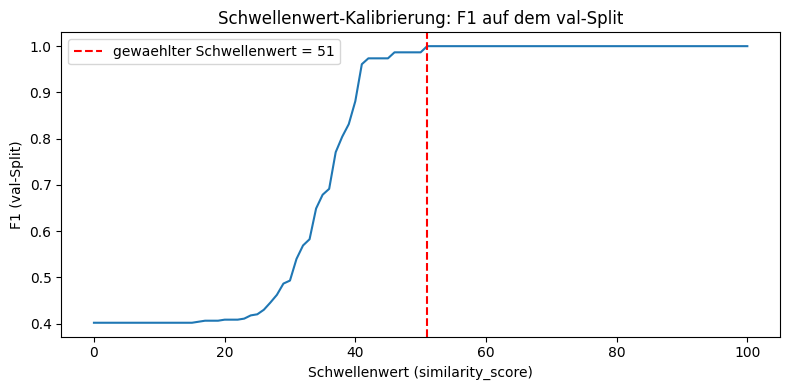

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(threshold_curve["threshold"], threshold_curve["f1_val"])
plt.axvline(best_threshold, color="red", linestyle="--", label=f"gewaehlter Schwellenwert = {best_threshold}")
plt.xlabel("Schwellenwert (similarity_score)")
plt.ylabel("F1 (val-Split)")
plt.title("Schwellenwert-Kalibrierung: F1 auf dem val-Split")
plt.legend()
plt.tight_layout()
plt.savefig("results/tf1_rapidfuzz_threshold_curve.png", dpi=120)
plt.show()


## 5. Evaluation auf dem `test`-Split (finales, berichtetes Ergebnis)

In [6]:
test = scored[scored["split"] == "test"].copy()
test["prediction"] = (test["similarity_score"] >= best_threshold).astype(int)

precision = precision_score(test["label"], test["prediction"])
recall = recall_score(test["label"], test["prediction"])
f1 = f1_score(test["label"], test["prediction"])

print(f"Test-Split ({len(test)} Paare), Schwellenwert={best_threshold}")
print(f"Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")
print()
print(classification_report(test["label"], test["prediction"], target_names=["kein Duplikat", "Duplikat"]))
print("Konfusionsmatrix:")
print(confusion_matrix(test["label"], test["prediction"]))


Test-Split (148 Paare), Schwellenwert=51
Precision: 0.949  Recall: 1.000  F1: 0.974

               precision    recall  f1-score   support

kein Duplikat       1.00      0.98      0.99       111
     Duplikat       0.95      1.00      0.97        37

     accuracy                           0.99       148
    macro avg       0.97      0.99      0.98       148
 weighted avg       0.99      0.99      0.99       148

Konfusionsmatrix:
[[109   2]
 [  0  37]]


## 6. Fehleranalyse: Falsch-Positive und Falsch-Negative

Für die qualitative Diskussion in Abschnitt 4.1.5 - welche Paare hat die Methode falsch
eingeordnet, und warum (z.B. sehr ähnliche, aber tatsächlich unterschiedliche Titel;
oder echte Duplikate mit stark abweichendem Titel)?


In [7]:
def show_pair(row):
    a, b = pool.loc[row["row_id_a"]], pool.loc[row["row_id_b"]]
    return {"title_a": a["title"], "title_b": b["title"], "url_score": row["url_score"],
            "title_score": row["title_score"], "bonus": row["bonus"], "score": row["similarity_score"],
            "label": row["label"], "prediction": row["prediction"]}

fp = test[(test["label"] == 0) & (test["prediction"] == 1)]
fn = test[(test["label"] == 1) & (test["prediction"] == 0)]
print(f"Falsch-Positive: {len(fp)}, Falsch-Negative: {len(fn)}")

fehler_beispiele = pd.DataFrame([show_pair(r) for _, r in pd.concat([fp, fn]).iterrows()])
fehler_beispiele


Falsch-Positive: 2, Falsch-Negative: 0


,title_a,title_b,url_score,title_score,bonus,score,label,prediction
0,Collect $100 CT Money on $250+ spend at Canadi...,Amex offer (YMMV) 3 times $10 credit on $10 pu...,0.0,51.315789,0.0,51.315789,0,1
1,TrekPow G39 1200A $67.99 57% off,Rhino 16000lbs ramp $69.99 + FS,0.0,47.619048,5.0,52.619048,0,1


## 7. Ergebnisse und Laufzeit-Log speichern

In [8]:
test_out = test[["row_id_a", "row_id_b", "label", "url_score", "title_score", "bonus",
                  "similarity_score", "prediction"]].copy()
test_out.to_csv("results/tf1_rapidfuzz_predictions.csv", index=False)

metrics = {
    "experiment": "TF1_Duplikate", "method": "Exact_RapidFuzz", "n_test": len(test),
    "threshold": best_threshold, "f1_val_at_threshold": best_f1,
    "precision": precision, "recall": recall, "f1": f1,
    "compute_time_sec_all_pairs": compute_time,
    "n_false_positives": int(len(fp)), "n_false_negatives": int(len(fn)),
}
with open("results/tf1_rapidfuzz_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

log_row = pd.DataFrame([{
    "experiment": "TF1_Duplikate", "method": "Exact_RapidFuzz", "n_items": len(test),
    "wall_time_sec": compute_time, "input_tokens": 0, "output_tokens": 0,
    "estimated_cost_usd": 0.0, "model_name": "rapidfuzz+url-exact (kein LLM/API)",
}])
log_path = "results/laufzeit_kosten_log.csv"
if os.path.exists(log_path):
    _old_log = pd.read_csv(log_path)
    _new_keys = set(zip(log_row["experiment"], log_row["method"]))
    _old_log = _old_log[~_old_log.apply(lambda r: (r["experiment"], r["method"]) in _new_keys, axis=1)]
    _combined_log = pd.concat([_old_log, log_row], ignore_index=True)
else:
    _combined_log = log_row
_combined_log.to_csv(log_path, index=False)

print(f"Gespeichert: results/tf1_rapidfuzz_predictions.csv, results/tf1_rapidfuzz_metrics.json")
print("Laufzeit-Log aktualisiert: results/laufzeit_kosten_log.csv")
print(json.dumps(metrics, indent=2))


Gespeichert: results/tf1_rapidfuzz_predictions.csv, results/tf1_rapidfuzz_metrics.json
Laufzeit-Log aktualisiert: results/laufzeit_kosten_log.csv
{
  "experiment": "TF1_Duplikate",
  "method": "Exact_RapidFuzz",
  "n_test": 148,
  "threshold": 51,
  "f1_val_at_threshold": 1.0,
  "precision": 0.9487179487179487,
  "recall": 1.0,
  "f1": 0.9736842105263158,
  "compute_time_sec_all_pairs": 0.6247386932373047,
  "n_false_positives": 2,
  "n_false_negatives": 0
}


**Hinweis für Abschnitt 4.1.4/4.1.5:** Da diese Methode praktisch kostenlos ist
(< 1 Sekunde für alle 736 Paare, kein API-Aufruf), dient sie im Laufzeit-/Kostenvergleich
(Abschnitt 4.5) als unterer Referenzpunkt gegenüber Splink (Abschnitt 4.1.2) und Claude
(Abschnitt 4.1.3).